# ***`Importation des bibliothèques`***

---



In [ ]:
import os
import zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ***`Chargement et extraction automatique du dataset PaySim`***

---



In [ ]:
# le nom du fichier CSV du dataset PaySim
DATA_PATH = "PS_20174392719_1491204439457_log.csv"

# le nom du fichier compressé téléchargé depuis Kaggle
ZIP_PATH  = "paysim1.zip"

if not os.path.exists(DATA_PATH):
    print("\n[INFO] Téléchargement du dataset via Kaggle API...")

    # Commande sert à télécharger le dataset PaySim depuis Kaggle grâce à l’API Kaggle.
    # Télécharge le dataset PaySim de l'utilisateur Kaggle ealaxi
    os.system("kaggle datasets download -d ealaxi/paysim1")
    if os.path.exists(ZIP_PATH):
        # Ouverture et extraction du fichier ZIP
        with zipfile.ZipFile(ZIP_PATH, 'r') as z:
            z.extractall(".")
        print("[INFO] Extraction terminée.")

    # Cette partie s’exécute si le fichier ZIP n’a pas été trouvé après le téléchargement.
    else:
        raise FileNotFoundError(
            "Fichier ZIP introuvable. Vérifiez votre clé API Kaggle.\n"
            "Alternative manuelle : téléchargez depuis\n"
            "https://www.kaggle.com/datasets/ealaxi/paysim1\n"
            "et placez le CSV dans le même dossier que ce script."
        )

df = pd.read_csv(DATA_PATH)


[INFO] Téléchargement du dataset via Kaggle API...
[INFO] Extraction terminée.


# ***`Exploration initiale du dataset`***

---



In [ ]:
from IPython.display import display, HTML

# Afficher Shape
display(HTML(f"""
<div style="
    background-color:#f8f9fa;
    padding:15px;
    border-left:5px solid #0d6efd;
    border-radius:8px;
    margin-bottom:10px;">
    <h3 style="margin:0;color:#0d6efd;">Dataset Shape</h3>
    <p style="font-size:18px;">
        {df.shape[0]} lignes × {df.shape[1]} colonnes
    </p>
</div>
"""))

# Afficher les 5 premières lignes
display(HTML("""
<h3 style="color:#0d6efd;">Aperçu des données</h3>
"""))

display(df.head().style
        .set_table_styles([
            {'selector':'th',
             'props':[('background-color','#0d6efd'),
                      ('color','white'),
                      ('text-align','center')]},
            {'selector':'td',
             'props':[('text-align','center')]}
        ])
        .hide(axis='index'))

# Afficher info()
import io

# StringIO() crée un espace mémoire qui se comporte comme un fichier texte.
buffer = io.StringIO()
df.info(buf=buffer)

display(HTML(f"""
<div style="
    background-color:#f8f9fa;
    padding:15px;
    border-radius:8px;
    border:1px solid #ddd;
    margin-top:15px;">
    <h3 style="color:#0d6efd;">Informations sur le dataset</h3>
    <pre>{buffer.getvalue()}</pre>
</div>
"""))

step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
1,PAYMENT,9839.640000,C1231006815,170136.000000,160296.360000,M1979787155,0.000000,0.000000,0,0
1,PAYMENT,1864.280000,C1666544295,21249.000000,19384.720000,M2044282225,0.000000,0.000000,0,0
1,TRANSFER,181.000000,C1305486145,181.000000,0.000000,C553264065,0.000000,0.000000,1,0
1,CASH_OUT,181.000000,C840083671,181.000000,0.000000,C38997010,21182.000000,0.000000,1,0
1,PAYMENT,11668.140000,C2048537720,41554.000000,29885.860000,M1230701703,0.000000,0.000000,0,0


In [ ]:
def dataset_report(df):
    print("📊 RAPPORT D'ANALYSE DU DATASET")
    print("=" * 60)

    print("\n📌 Shape du dataset")
    print(f"Lignes : {df.shape[0]} | Colonnes : {df.shape[1]}")

    print("\n📌 Types des variables")
    print(df.dtypes)

    print("\n📌 Statistiques descriptives")
    print(df.describe())

    print("\n📌 Valeurs manquantes")
    missing = df.isnull().sum()
    print(missing[missing > 0] if missing.sum() > 0 else "Aucune valeur manquante")

    print("\n📌 Lignes dupliquées")
    print(f"{df.duplicated().sum()} lignes dupliquées")

# exécution
dataset_report(df)

📊 RAPPORT D'ANALYSE DU DATASET

📌 Shape du dataset
Lignes : 6362620 | Colonnes : 11

📌 Types des variables
step                int64
type               object
amount            float64
nameOrig           object
oldbalanceOrg     float64
newbalanceOrig    float64
nameDest           object
oldbalanceDest    float64
newbalanceDest    float64
isFraud             int64
isFlaggedFraud      int64
dtype: object

📌 Statistiques descriptives
               step        amount  oldbalanceOrg  newbalanceOrig  \
count  6.362620e+06  6.362620e+06   6.362620e+06    6.362620e+06   
mean   2.433972e+02  1.798619e+05   8.338831e+05    8.551137e+05   
std    1.423320e+02  6.038582e+05   2.888243e+06    2.924049e+06   
min    1.000000e+00  0.000000e+00   0.000000e+00    0.000000e+00   
25%    1.560000e+02  1.338957e+04   0.000000e+00    0.000000e+00   
50%    2.390000e+02  7.487194e+04   1.420800e+04    0.000000e+00   
75%    3.350000e+02  2.087215e+05   1.073152e+05    1.442584e+05   
max    7.430000e+02 

Non-Fraude : 6,354,407 (99.8709%)
Fraude     : 8,213 (0.1291%)


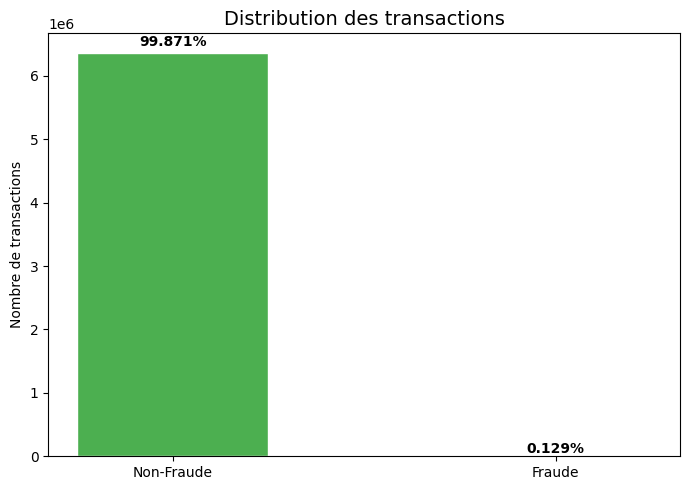

In [ ]:
# Calcul des pourcentages
# le nombre de transactions (fraudes / non fraudes)
fraud_counts = df['isFraud'].value_counts()

fraud_pct = df['isFraud'].value_counts(normalize=True) * 100

print(f"Non-Fraude : {fraud_counts[0]:,} ({fraud_pct[0]:.4f}%)")
print(f"Fraude     : {fraud_counts[1]:,} ({fraud_pct[1]:.4f}%)")

# Graphique en barres uniquement
plt.figure(figsize=(7,5))

labels = ['Non-Fraude', 'Fraude']
colors = ['#4CAF50', '#E53935']

bars = plt.bar(labels, fraud_counts, color=colors,
               edgecolor='white', width=0.5)

# Affichage des pourcentages au-dessus des barres
for bar, pct in zip(bars, fraud_pct):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() * 1.01,
        f'{pct:.3f}%',
        ha='center',
        va='bottom',
        fontweight='bold'
    )

plt.title('Distribution des transactions', fontsize=14)
plt.ylabel('Nombre de transactions')

plt.tight_layout()
plt.savefig('fraud_distribution.png', dpi=150)
plt.show()

# **[Analyse des types de transactions]**

---



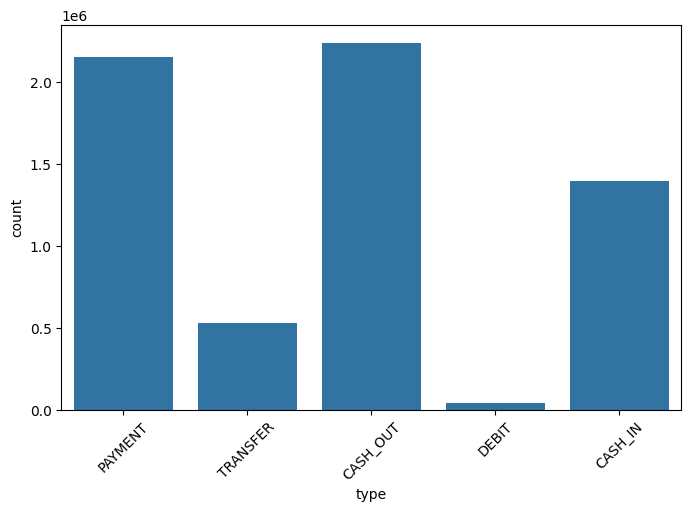

In [ ]:
df['type'].value_counts()
plt.figure(figsize=(8,5))
sns.countplot(x='type', data=df)
plt.xticks(rotation=45)
plt.show()

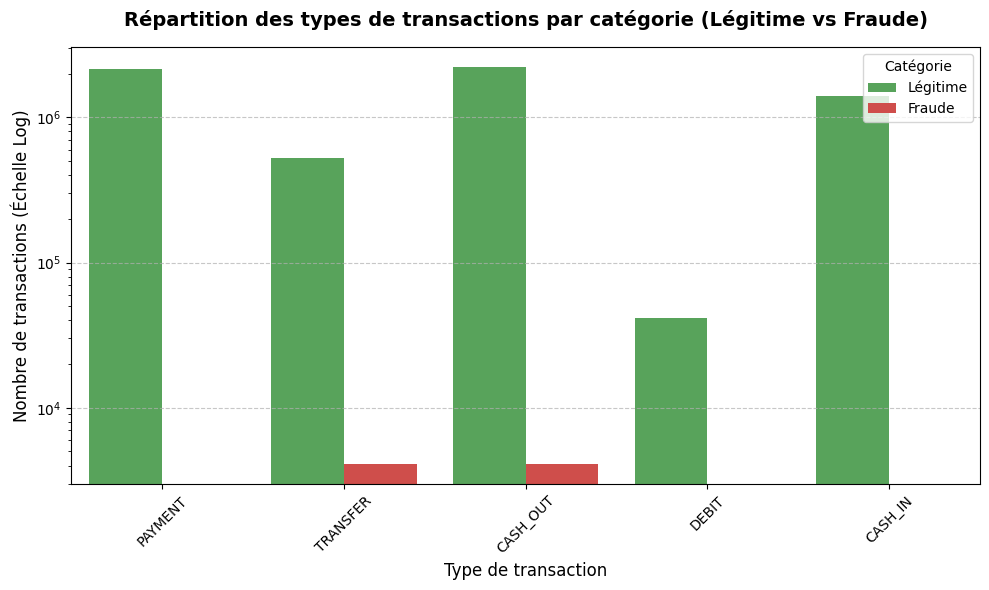

isFraud,0,1
type,,
CASH_IN,100.0 %,0.0 %
CASH_OUT,99.82 %,0.18 %
DEBIT,100.0 %,0.0 %
PAYMENT,100.0 %,0.0 %
TRANSFER,99.23 %,0.77 %


In [ ]:
# Configuration de la taille de la figure
plt.figure(figsize=(10, 6))

# Création du graphique en séparant par la colonne 'isFraud'
ax = sns.countplot(x='type', hue='isFraud', data=df, palette=['#4CAF50', '#E53935'])

# Passage en échelle logarithmique pour mieux visualiser les fraudes (très minoritaires)
plt.yscale('log')

# Personnalisation des titres et labels
plt.title("Répartition des types de transactions par catégorie (Légitime vs Fraude)", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Type de transaction", fontsize=12)
plt.ylabel("Nombre de transactions (Échelle Log)", fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Configuration et personnalisation de la légende
legend_labels = ['Légitime', 'Fraude']
plt.legend(handles=ax.get_legend_handles_labels()[0], labels=legend_labels, title="Catégorie", loc='upper right')

# Affichage propre
plt.tight_layout()
plt.show()

ct = pd.crosstab(
    df['type'],
    df['isFraud'],
    normalize='index'
) * 100

ct.round(2).astype(str) + " %"

# ***Montant des transactions***

---



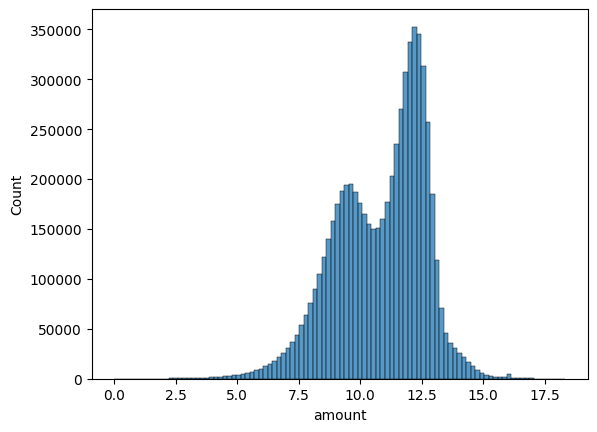

In [ ]:
sns.histplot(np.log1p(df['amount']), bins=100)
plt.show()

Les valeurs aberrantes ne doivent pas être supprimées car ils peuvent représenter des comportements frauduleux

# ***`Matrice de corrélation des variables numériques`***

---



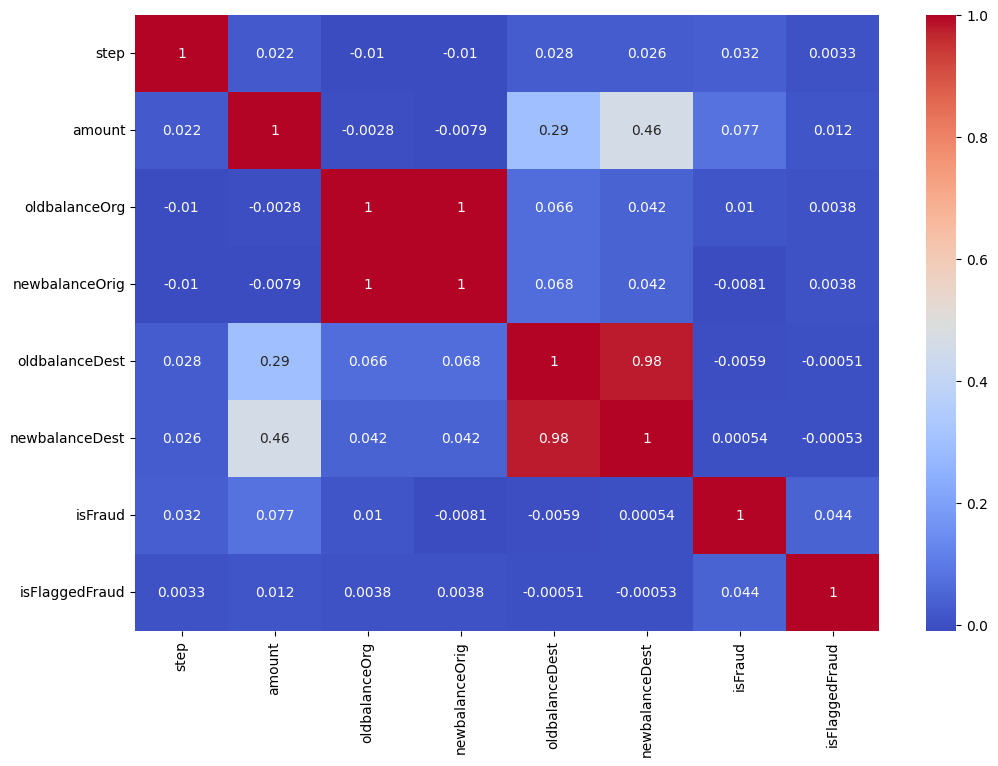

In [ ]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(12,8))
sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm'
)
plt.show()

In [1]:
!ls /content

sample_data


In [2]:
!git --version

git version 2.43.0


In [3]:
!git config --global user.name "Chaabmanal2022"
!git config --global user.email "manalchaab2002@gmail.com"

In [4]:
!git config --global user.name
!git config --global user.email

Chaabmanal2022
manalchaab2002@gmail.com


In [5]:
%cd /content

/content


In [6]:
!git init

hint: Using 'master' as the name for the initial branch. This default branch name
hint: is subject to change. To configure the initial branch name to use in all
hint: of your new repositories, which will suppress this warning, call:
hint: 
hint: 	git config --global init.defaultBranch <name>
hint: 
hint: Names commonly chosen instead of 'master' are 'main', 'trunk' and
hint: 'development'. The just-created branch can be renamed via this command:
hint: 
hint: 	git branch -m <name>
Initialized empty Git repository in /content/.git/


In [7]:
!git status

On branch master

No commits yet

Untracked files:
  (use "git add <file>..." to include in what will be committed)
	.config/
	sample_data/

nothing added to commit but untracked files present (use "git add" to track)


In [8]:
%%writefile .gitignore
sample_data/
__pycache__/
*.pyc
.ipynb_checkpoints/
.env

Writing .gitignore


In [9]:
!git status

On branch master

No commits yet

Untracked files:
  (use "git add <file>..." to include in what will be committed)
	.config/
	.gitignore

nothing added to commit but untracked files present (use "git add" to track)


In [13]:
!git checkout -b First-branch

Switched to a new branch 'First-branch'


In [14]:
!git branch

In [15]:
!git remote add origin https://github.com/Chaabmanal2022/Balancing-PR-AUC-and-Explanation-Stability-in-Fraud-Detection.git

In [16]:
!git remote -v

origin	https://github.com/Chaabmanal2022/Balancing-PR-AUC-and-Explanation-Stability-in-Fraud-Detection.git (fetch)
origin	https://github.com/Chaabmanal2022/Balancing-PR-AUC-and-Explanation-Stability-in-Fraud-Detection.git (push)


In [21]:
!git add "Analyse_Dataset.ipynb"

fatal: pathspec 'Analyse_Dataset.ipynb' did not match any files


In [22]:
!git add .

In [23]:
!git status

On branch First-branch

No commits yet

Changes to be committed:
  (use "git rm --cached <file>..." to unstage)
	new file:   .config/.last_opt_in_prompt.yaml
	new file:   .config/.last_survey_prompt.yaml
	new file:   .config/.last_update_check.json
	new file:   .config/active_config
	new file:   .config/config_sentinel
	new file:   .config/configurations/config_default
	new file:   .config/default_configs.db
	new file:   .config/gce
	new file:   .config/hidden_gcloud_config_universe_descriptor_data_cache_configs.db
	new file:   .config/logs/2026.09.16/13.25.37.877256.log
	new file:   .config/logs/2026.09.16/13.26.04.283691.log
	new file:   .config/logs/2026.09.16/13.26.15.129583.log
	new file:   .config/logs/2026.09.16/13.26.17.091876.log
	new file:   .config/logs/2026.09.16/13.26.29.139725.log
	new file:   .config/logs/2026.09.16/13.26.30.459687.log
	new file:   .gitignore



In [24]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [25]:
import google.colab

# Récupère le nom du notebook et recherche son chemin exact
notebook_name = "Analyse_Dataset.ipynb"
!find /content/drive/MyDrive -name "{notebook_name}" 2>/dev/null

/content/drive/MyDrive/Colab Notebooks/Analyse_Dataset.ipynb


In [26]:
!cp "/content/drive/MyDrive/Colab Notebooks/Analyse_Dataset.ipynb"

cp: missing destination file operand after '/content/drive/MyDrive/Colab Notebooks/Analyse_Dataset.ipynb'
Try 'cp --help' for more information.
